In [17]:
from PIL import Image, ImageOps
import numpy as np

def load_img_consistent(path, max_size=1200):
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)
    
    w, h = img.size
    scale = max(w, h) / max_size
    print(scale)
    if scale > 1:
        new_size = (int(w / scale), int(h / scale))
        img = img.resize(new_size, Image.LANCZOS)
        print(f"Resized from {w}×{h} → {new_size}")
    
    return np.array(img)

def normalize_points(pts):
    mean = pts.mean(axis=0)
    std  = pts.std(axis=0).mean()
    s = np.sqrt(2) / std
    T = np.array([[s, 0, -s*mean[0]],
                  [0, s, -s*mean[1]],
                  [0, 0, 1]])
    pts_h = np.c_[pts, np.ones(len(pts))].T
    npts = (T @ pts_h).T[:, :2]
    return npts, T

import numpy as np

def reprojection_errors(H, im1_pts, im2_pts):
    #im1 -> im2
    n = im1_pts.shape[0]
    p1 = np.c_[im1_pts, np.ones(n)]
    p2_hat = (H @ p1.T).T
    p2_hat = p2_hat[:, :2] / p2_hat[:, 2:3]

    #im2 -> im1 (consistency)
    Hinv = np.linalg.inv(H)
    p2 = np.c_[im2_pts, np.ones(n)]
    p1_hat = (Hinv @ p2.T).T
    p1_hat = p1_hat[:, :2] / p1_hat[:, 2:3]

    err_fwd = np.linalg.norm(p2_hat - im2_pts, axis=1)
    err_bwd = np.linalg.norm(p1_hat - im1_pts, axis=1)
    return err_fwd, err_bwd

def warp_bounds(im, H):
    h, w = im.shape[:2]
    corners = np.array([[0,0,1],[w,0,1],[0,h,1],[w,h,1]]).T
    wc = H @ corners
    wc /= wc[2]
    xs, ys = wc[0], wc[1]
    min_x, max_x = np.floor(xs.min()), np.ceil(xs.max())
    min_y, max_y = np.floor(ys.min()), np.ceil(ys.max())
    tx = -min_x if min_x < 0 else 0
    ty = -min_y if min_y < 0 else 0
    T = np.array([[1,0,tx],[0,1,ty],[0,0,1]])
    out_w = int(max_x - min_x)
    out_h = int(max_y - min_y)
    return (out_h, out_w), T

In [18]:
def computeH(im1_pts, im2_pts):
    # nnormalize
    p1n, T1 = normalize_points(im1_pts)
    p2n, T2 = normalize_points(im2_pts)

    N = im1_pts.shape[0]
    A = []
    for i in range(N):
        x, y = p1n[i]
        u, v = p2n[i]
        A.append([ x, y, 1, 0, 0, 0, -u*x, -u*y, -u])
        A.append([ 0, 0, 0, x, y, 1, -v*x, -v*y, -v])
    A = np.array(A)

    _, _, Vt = np.linalg.svd(A)
    Hn = Vt[-1].reshape(3,3)
    # Denormalize:
    # # H = T2^{-1} Hn T1
    H = np.linalg.inv(T2) @ Hn @ T1
    return H / H[2,2]

In [112]:
%matplotlib qt

In [114]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

def pick_points(image_path, n, title):
    img = load_img_consistent(image_path)
    fig, ax = plt.subplots()
    ax.imshow(img)  
    # no rotation now
    ax.set_title(title)
    pts = np.array(plt.ginput(n, timeout=-1, show_clicks=True), dtype=float)
    plt.close(fig)
    return pts


N = 8  # 
# im1_path = "/Users/jaitegchahal/cs180/jaitegchahal123.github.io/proj3/media/IMG_5781.jpg"
# im2_path = "/Users/jaitegchahal/cs180/jaitegchahal123.github.io/proj3/media/IMG_5782.jpg"
im1_path = "/Users/jaitegchahal/cs180/jaitegchahal123.github.io/proj3/media/IMG_5876.jpg"
im2_path = "/Users/jaitegchahal/cs180/jaitegchahal123.github.io/proj3/media/IMG_5877.jpg"

print(f"Select {N} points on LEFT image (in order).")
im1_pts = pick_points(im1_path, N, "LEFT image")

print(f"Select {N} MATCHING points on RIGHT image in the SAME order.")
im2_pts = pick_points(im2_path, N, "RIGHT image")

# im1_pts[i] ↔ im2_pts[i]


Select 8 points on LEFT image (in order).
4.76
Resized from 4284×5712 → (900, 1200)
Select 8 MATCHING points on RIGHT image in the SAME order.
4.76
Resized from 4284×5712 → (900, 1200)


In [115]:
print(im1_pts)
print(im2_pts)

[[ 705.99350649  328.72077922]
 [ 680.01948052  604.69480519]
 [ 676.77272727  702.0974026 ]
 [ 647.55194805 1026.77272727]
 [ 761.18831169 1062.48701299]
 [ 861.83766234 1078.72077922]
 [ 829.37012987  383.91558442]
 [ 680.01948052  646.9025974 ]]
[[ 218.98051948  351.44805195]
 [ 235.21428571  630.66883117]
 [ 238.46103896  724.82467532]
 [ 251.44805195 1068.98051948]
 [ 365.08441558 1059.24025974]
 [ 452.74675325 1046.25324675]
 [ 345.6038961   413.13636364]
 [ 231.96753247  672.87662338]]


In [116]:
H = computeH(im1_pts, im2_pts)
print(H)

[[ 2.09608398e+00  2.32920739e-01 -1.15862220e+03]
 [ 5.62121517e-01  1.80516954e+00 -3.57639531e+02]
 [ 1.12747510e-03  1.27164910e-05  1.00000000e+00]]


In [4]:
import matplotlib.pyplot as plt
im1 = load_img_consistent(im1_path)
im2 = load_img_consistent(im2_path)
def visualize_projection(H, im1, im2, im1_pts, im2_pts, title=""):
    # project im1_pts -> im2 frame
    p1 = np.c_[im1_pts, np.ones(len(im1_pts))]
    proj = (H @ p1.T).T
    proj = proj[:, :2] / proj[:, 2:3]

    plt.figure(figsize=(7,7))
    plt.imshow(im2)
    plt.scatter(im2_pts[:,0], im2_pts[:,1], s=40, c='lime', label='clicked im2_pts')
    plt.scatter(proj[:,0],   proj[:,1],   s=40, facecolors='none', edgecolors='red', label='H * im1_pts')
    for i,(a,b) in enumerate(zip(im2_pts, proj)):
        plt.plot([a[0], b[0]], [a[1], b[1]], 'y-', linewidth=1)
        plt.text(a[0]+3, a[1]+3, str(i), color='white', fontsize=9)
        plt.text(b[0]+3, b[1]+3, str(i), color='red', fontsize=9)
    plt.legend(); plt.title(title); plt.axis('off'); plt.show()

visualize_projection(H, im1, im2, im1_pts, im2_pts, "Projection check: im1 -> im2")


NameError: name 'im1_path' is not defined

In [19]:
def warpImageNearestNeighbor(im, H, out_shape):
    H_inv = np.linalg.inv(H)
    h_out, w_out = out_shape
    warped_im = np.zeros((h_out, w_out, im.shape[2]), dtype=im.dtype)

    for i in range(h_out):
        for j in range(w_out):
            p_out = np.array([j, i, 1])
            p_in = H_inv @ p_out
            p_in /= p_in[2]
            x_in, y_in = int(round(p_in[0])), int(round(p_in[1]))

            if 0 <= x_in < im.shape[1] and 0 <= y_in < im.shape[0]:
                warped_im[i, j] = im[y_in, x_in]

    return warped_im

In [20]:
def warpImageBilinear(im, H, out_shape):
    H_inv = np.linalg.inv(H)
    h_out, w_out = out_shape
    C = im.shape[2]
    warped = np.zeros((h_out, w_out, C), dtype=np.float32)

    for i in range(h_out):
        for j in range(w_out):
            xw, yw, w = H_inv @ np.array([j, i, 1.0])
            if w == 0: 
                continue
            x = xw / w; y = yw / w
            if 0 <= x < im.shape[1]-1 and 0 <= y < im.shape[0]-1:
                x0, y0 = int(np.floor(x)), int(np.floor(y))
                dx, dy = x - x0, y - y0
                x1, y1 = x0 + 1, y0 + 1

                # vectorized over channels
                top    = (1 - dx) * im[y0, x0, :].astype(np.float32) + dx * im[y0, x1, :].astype(np.float32)
                bottom = (1 - dx) * im[y1, x0, :].astype(np.float32) + dx * im[y1, x1, :].astype(np.float32)
                warped[i, j, :] = (1 - dy) * top + dy * bottom

    return np.clip(warped, 0, 255).astype(im.dtype)

In [84]:
im1 = load_img_consistent(im1_path)
im2 = load_img_consistent(im2_path)
h_out, w_out = im2.shape[0], im2.shape[1]  
#canvas = im2’s frame

imwarped_nn = warpImageNearestNeighbor(im1, H, (h_out, w_out))
imwarped_bilinear = warpImageBilinear(im1, H, (h_out, w_out))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imwarped_nn)
axs[0].set_title("Nearest Neighbor")
axs[1].imshow(imwarped_bilinear)
axs[1].set_title("Bilinear Interpolation")
plt.show()

4.76
Resized from 4284×5712 → (900, 1200)
4.76
Resized from 4284×5712 → (900, 1200)


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(imwarped_nn)
plt.title("Nearest Neighbor")
plt.axis('off')

rando = Image.fromarray(imwarped_nn)
rando.save("./media/warpednn.png")

plt.figure()
plt.imshow(imwarped_bilinear)
plt.title("Bilinear Interpolation")
plt.axis('off')

rand1 = Image.fromarray(imwarped_bilinear)
rand1.save("./media/warpedbil.png")

plt.show()


In [7]:
def order_corners_TL_TR_BR_BL(pts):
    pts = np.asarray(pts, float)
    c = pts.mean(axis=0)
    ang = np.arctan2(pts[:,1]-c[1], pts[:,0]-c[0])
    pts = pts[np.argsort(ang)]                     # CCW
    start = np.argmin(pts.sum(axis=1))             # TL first
    return np.roll(pts, -start, axis=0)            # TL,TR,BR,BL

def rectify_full_canvas_trapezoid(image_path, a=800, method="nearest"):
    # 1) Click 4 corners of the planar patch (any order is fine)
    clicks = pick_points(image_path, 4, "Pick 4 corners (any order)")
    src = order_corners_TL_TR_BR_BL(clicks)        # TL, TR, BR, BL

    # 2) Destination = fixed rectangle (square) in the SAME order
    dst = np.array([[0,0], [a-1,0], [a-1,a-1], [0,a-1]], dtype=float)

    # 3) Compute H (your normalized DLT)
    H = computeH(src, dst)                         # maps input -> rectified frame
    print(H)
    # 4) Build an output canvas that fits the WHOLE image after warping by H
    im = load_img_consistent(image_path)  
             # HxWxC (uint8)
    out_shape, T = warp_bounds(im, H)              # your function
    max_side = 1400  # tune this (e.g., 1200–1600)
    scale = min(max_side / out_shape[0], max_side / out_shape[1], 1.0)

    if scale < 1.0:
        S = np.array([[scale, 0, 0],
                    [0, scale, 0],
                    [0,     0, 1]])
        H_total = S @ T @ H
        out_shape = (int(out_shape[0] * scale), int(out_shape[1] * scale))
    else:
        H_total = T @ H

    print("Capped canvas:", out_shape)                      # translate so min x/y are 0

    # 5) Warp with your NN/Bilinear
    if method.lower().startswith("bil"):
        warped = warpImageBilinear(im, H_total, out_shape)
    else:
        print('nearest neighbor')
        warped = warpImageNearestNeighbor(im, H_total, out_shape)

    Image.fromarray(warped.astype(np.uint8)).save("rectified_trapezoid.png")
    print("Saved -> rectified_trapezoid.png")
    return H, H_total, warped, out_shape


In [102]:
im1_path = "/Users/jaitegchahal/cs180/jaitegchahal123.github.io/proj3/media/floor.jpg"
H, H_total, warped, out_shape = rectify_full_canvas_trapezoid(
    im1_path, a=800, method="nearest"   # or "nearest"
)

4.76
Resized from 4284×5712 → (900, 1200)


KeyboardInterrupt: 

In [21]:
def mosaic_bounds(im1, im2, H):
    h1, w1 = im1.shape[:2]
    h2, w2 = im2.shape[:2]
    corners1 = np.array([[0,0,1],[w1,0,1],[0,h1,1],[w1,h1,1]]).T
    corners2 = np.array([[0,0,1],[w2,0,1],[0,h2,1],[w2,h2,1]]).T

    warped_corners1 = H @ corners1
    warped_corners1 /= warped_corners1[2]

    all_x = np.hstack([warped_corners1[0], corners2[0]])
    all_y = np.hstack([warped_corners1[1], corners2[1]])

    min_x, max_x = np.floor(all_x.min()), np.ceil(all_x.max())
    min_y, max_y = np.floor(all_y.min()), np.ceil(all_y.max())

    tx = -min_x if min_x < 0 else 0
    ty = -min_y if min_y < 0 else 0
    T = np.array([[1,0,tx],[0,1,ty],[0,0,1]])
    out_w, out_h = int(max_x - min_x), int(max_y - min_y)
    return (out_h, out_w), T


In [120]:
out_shape, T = mosaic_bounds(im1, im2, H)
H_total = T @ H
im1_warped = warpImageBilinear(im1, H_total, out_shape)


In [121]:
mosaic = np.zeros_like(im1_warped)
h2, w2 = im2.shape[:2]

for i in range(h2):
    for j in range(w2):
        x, y = int(j + T[0,2]), int(i + T[1,2])
        if 0 <= y < mosaic.shape[0] and 0 <= x < mosaic.shape[1]:
            mosaic[y, x] = im2[i, j]


In [9]:
import numpy as np
from scipy.ndimage import distance_transform_edt

def alpha_from_valid(mask):
    return distance_transform_edt(mask) / (distance_transform_edt(~mask) + 1e-6)

valid1 = (im1_warped.sum(axis=2) > 0)
valid2 = (mosaic.sum(axis=2) > 0)

a1 = alpha_from_valid(valid1)
a2 = alpha_from_valid(valid2)

bias = 1.5
a2 *= bias

W = (a1 + a2 + 1e-6)[..., None]
mosaic_blend = (im1_warped * a1[...,None] + mosaic * a2[...,None]) / W
mosaic_blend = np.clip(mosaic_blend, 0, 255).astype(np.uint8)

NameError: name 'im1_warped' is not defined

In [123]:
plt.imshow(mosaic_blend.astype(np.uint8))
plt.title("Blended Mosaic")
plt.axis('off')
plt.show()

In [124]:
img = Image.fromarray(mosaic_blend.astype(np.uint8))
img.save("./media/mosaic_lib.png")

### Part B

In [22]:
import numpy as np
from skimage.feature import corner_harris, peak_local_max

# -------------------- Starter (unchanged) --------------------
def get_harris_corners(im, edge_discard=20):
    """
    Finds Harris corners and returns:
      h:   Harris response map (same shape as im)
      coords: 2 x N array with (ys, xs) of detected corners, edges discarded
    """
    assert edge_discard >= 20

    h = corner_harris(im, method='eps', sigma=1)  # allowed helper
    coords = peak_local_max(h, min_distance=1, threshold_rel=0.01)    # allowed helper

    # discard points near edges
    edge = edge_discard
    mask = (coords[:, 0] > edge) & \
           (coords[:, 0] < im.shape[0] - edge) & \
           (coords[:, 1] > edge) & \
           (coords[:, 1] < im.shape[1] - edge)
    coords = coords[mask].T  # (2, N) as (ys; xs)
    return h, coords

def dist2(x, c):
    """
    Squared Euclidean distance between rows of x and rows of c.
    x: MxD, c: LxD -> returns MxL matrix
    """
    ndata, dimx = x.shape
    ncenters, dimc = c.shape
    assert dimx == dimc, 'Data dimension does not match dimension of centers'
    return (np.ones((ncenters, 1)) * np.sum((x**2).T, axis=0)).T + \
           np.ones((ndata,   1)) * np.sum((c**2).T, axis=0)    - \
           2 * np.inner(x, c)

def anms(coords, h, N=500, c_robust=0.9):
    if coords.size == 0:
        return coords
    ys, xs = coords
    vals = h[ys, xs]
    order = np.argsort(-vals)        # strong → weak
    ys, xs, vals = ys[order], xs[order], vals[order]
    K = len(vals)

    radii = np.full(K, np.inf, dtype=np.float32)
    for j in range(1, K):
        mask = (np.arange(j) >= 0) & (vals[:j] >= c_robust*vals[j])
        if not np.any(mask): 
            continue
        dy = ys[:j][mask] - ys[j]
        dx = xs[:j][mask] - xs[j]
        r2 = dx*dx + dy*dy
        radii[j] = np.sqrt(r2.min())

    if np.isinf(radii[0]):
        finite = radii[np.isfinite(radii)]
        radii[0] = finite.max() if finite.size else 1e6

    keep = np.argsort(-radii)[:N]
    return np.vstack([ys[keep], xs[keep]])


# -------------------- (Optional) Simple overlay saving --------------------
# Only used to save your deliverable images with corners drawn.
# You can remove this section if you prefer saving in your notebook.
import matplotlib.pyplot as plt

def save_corners_overlay(rgb_image, coords, out_path, title=None, s=12):
    """
    rgb_image: HxWx3 (uint8 or float) array
    coords: 2xN (ys; xs)
    """
    fig, ax = plt.subplots(figsize=(8, 8*rgb_image.shape[0]/rgb_image.shape[1]))
    ax.imshow(rgb_image)
    if coords.size:
        ys, xs = coords
        ax.scatter(xs, ys, s=s, facecolors='none', edgecolors='#e11d48', linewidths=1.2)
    if title: ax.set_title(title)
    ax.axis('off'); fig.tight_layout(pad=0.1)
    fig.savefig(out_path, dpi=200, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

In [14]:
from skimage.io import imread
from skimage.color import rgb2gray
import skimage.transform as tf
from skimage.color import rgb2gray
from skimage.transform import rescale

img_path = "./media/IMG_5782.jpg"  # change per your dataset
rgb = imread(img_path)
gray = rgb2gray(rgb).astype(np.float32)

im_small = rescale(gray, 0.5, anti_aliasing=True)

scale = 0.5
rgb_small = rescale(rgb, scale, channel_axis=-1, anti_aliasing=True)

h, coords_all = get_harris_corners(im_small, edge_discard=20)

save_corners_overlay(rgb_small, coords_all, "./media/harris_all.png",
                     title="Harris Corners (no ANMS)")
coords_anms = anms(coords_all, h, N=500, c_robust=0.9)
save_corners_overlay(rgb_small, coords_anms, "./media/harris_anms.png",
                     title="Harris Corners (with ANMS)")


print(f"All corners: {coords_all.shape[1]} | ANMS kept: {coords_anms.shape[1]}")

All corners: 29079 | ANMS kept: 500


In [23]:
def bilinear_sample_gray(im, ys, xs):
    """
    im: HxW float32
    ys, xs: arrays of same shape with float coordinates
    returns sampled patch with same shape
    """
    H, W = im.shape
    y0 = np.floor(ys).astype(np.int32)
    x0 = np.floor(xs).astype(np.int32)
    y1 = np.clip(y0 + 1, 0, H - 1)
    x1 = np.clip(x0 + 1, 0, W - 1)
    y0 = np.clip(y0, 0, H - 1)
    x0 = np.clip(x0, 0, W - 1)

    wy = ys - y0
    wx = xs - x0

    Ia = im[y0, x0]
    Ib = im[y0, x1]
    Ic = im[y1, x0]
    Id = im[y1, x1]

    top = Ia * (1 - wx) + Ib * wx
    bot = Ic * (1 - wx) + Id * wx
    return top * (1 - wy) + bot * wy

# ---------- Small Gaussian blur (separable) ----------
def gaussian_kernel1d(sigma, radius=None):
    if radius is None:
        radius = int(np.ceil(3 * sigma))
    x = np.arange(-radius, radius + 1, dtype=np.float32)
    k = np.exp(-(x**2) / (2 * sigma * sigma))
    k /= k.sum()
    return k

def gaussian_blur2d(im, sigma=1.0):
    if sigma <= 0:
        return im.copy()
    k = gaussian_kernel1d(sigma)
    # horizontal
    pad = len(k) // 2
    im_pad = np.pad(im, ((0,0),(pad,pad)), mode='edge')
    tmp = np.zeros_like(im, dtype=np.float32)
    for i in range(im.shape[0]):
        row = im_pad[i]
        tmp[i] = np.convolve(row, k, mode='valid')
    # vertical
    im_pad = np.pad(tmp, ((pad,pad),(0,0)), mode='edge')
    out = np.zeros_like(im, dtype=np.float32)
    for j in range(im.shape[1]):
        col = im_pad[:, j]
        out[:, j] = np.convolve(col, k, mode='valid')
    return out

# ---------- Descriptor extraction ----------
def extract_descriptors_8x8(
    im_gray,
    coords,                   # (2, N) = (ys; xs) at the SAME scale as im_gray
    win_size=40,              # 40x40 sampling window
    desc_size=8,              # 8x8 descriptor
    blur_sigma=1.0            # blur before pooling (per Brown et al.)
):
    H, W = im_gray.shape
    half = win_size // 2      # assumes even win_size (40)

    ys, xs = coords
    keep = (ys >= half) & (ys < H - half) & (xs >= half) & (xs < W - half)
    ys = ys[keep]; xs = xs[keep]

    # Regular grid relative to the keypoint center
    gy = np.linspace(-half + 0.5, half - 0.5, win_size, dtype=np.float32)
    gx = np.linspace(-half + 0.5, half - 0.5, win_size, dtype=np.float32)
    grid_y, grid_x = np.meshgrid(gy, gx, indexing='ij')

    descs = []
    kept_coords = []

    for y, x in zip(ys, xs):
        # sample 40x40 via bilinear
        Y = grid_y + y
        X = grid_x + x
        patch = bilinear_sample_gray(im_gray, Y, X).astype(np.float32)

        # blur
        patch = gaussian_blur2d(patch, sigma=blur_sigma)

        # average-pool 5x5 -> 8x8 (since 40/8 = 5 exactly)
        patch = patch.reshape(desc_size, 5, desc_size, 5).mean(3).mean(1)

        # bias/gain normalize (zero mean, unit variance)
        vec = patch.flatten()
        mu = vec.mean()
        sd = vec.std()
        vec = (vec - mu) / (sd + 1e-6)

        descs.append(vec)
        kept_coords.append((y, x))

    if len(descs) == 0:
        return np.zeros((0, desc_size*desc_size), dtype=np.float32), np.zeros((2,0), dtype=int)

    D = np.vstack(descs).astype(np.float32)            # M x 64
    #kept_coords = np.array(kept_coords, dtype=int).T   # (2, M)
    kept_coords = np.array(kept_coords, dtype=np.float32).T
    return D, kept_coords


def visualize_some_patches(im_gray, coords, n=12, win_size=40, out_path="patches.png"):
    half = win_size // 2
    idx = np.linspace(0, coords.shape[1]-1, n, dtype=int) if coords.shape[1] >= n else np.arange(coords.shape[1])
    fig, axes = plt.subplots(3, int(np.ceil(n/3)), figsize=(10, 6))
    axes = np.ravel(axes)
    for ax, i in zip(axes, idx):
        y, x = coords[:, i]
        y0, y1 = y - half, y + half
        x0, x1 = x - half, x + half
        # simple nearest extraction just for display (not used in descriptors)
        ax.imshow(im_gray[y0:y1, x0:x1], cmap='gray')
        ax.set_title(f"({y},{x})")
        ax.axis('off')
    for ax in axes[len(idx):]:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close(fig)


Descriptors: (500, 64) Keypoints kept: 500


TypeError: slice indices must be integers or None or have an __index__ method

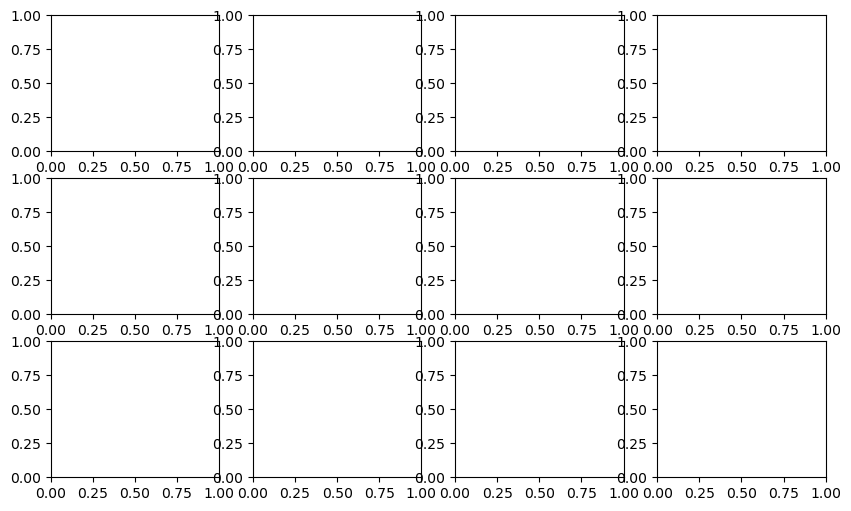

In [24]:
D, kp_coords = extract_descriptors_8x8(
    im_gray=im_small,             # grayscale image used for detection
    coords=coords_anms,           # interest points at this scale
    win_size=40,
    desc_size=8,
    blur_sigma=1.0
)
print("Descriptors:", D.shape, "Keypoints kept:", kp_coords.shape[1])
# Example:
visualize_some_patches(im_small, kp_coords, n=12, win_size=40,
                       out_path="./media/feature_patches.png")

In [25]:
def pairwise_sq_dists(A, B):
    """
    A: MxD, B: NxD  ->  MxN matrix of squared L2 distances
    """
    Aa = np.sum(A*A, axis=1, keepdims=True)      # Mx1
    Bb = np.sum(B*B, axis=1, keepdims=True).T    # 1xN
    return Aa + Bb - 2.0 * (A @ B.T)

def match_descriptors(D1, D2, ratio_thresh=0.7, mutual=True):
        # squared L2 distances MxN
    dist = pairwise_sq_dists(D1, D2)  # MxN
    M, N = dist.shape

    # best / second-best per row (D1 -> D2)
    order = np.argsort(dist, axis=1)            # MxN
    best = order[:, 0]
    second = order[:, 1]
    d_best = dist[np.arange(M), best]
    d_second = dist[np.arange(M), second]

    # Lowe ratio
    ratio = d_best / (d_second + 1e-12)
    keep = ratio < ratio_thresh

    # absolute distance gate (robust)
    med = np.median(d_best[keep]) if np.any(keep) else np.median(d_best)
    gate = med * 1.5  # 1.5–2.0 works well
    keep &= d_best < gate

    i1 = np.nonzero(keep)[0]
    i2 = best[keep]

    if not mutual or len(i1) == 0:
        return i1, i2, ratio[keep]

    # mutual (D2 -> D1)
    best_back = np.argmin(dist, axis=0)         # N
    mutual_mask = best_back[i2] == i1
    return i1[mutual_mask], i2[mutual_mask], ratio[keep][mutual_mask]

def show_matches(img1, kp1, img2, kp2, idx1, idx2, max_draw=120, title="Matches"):
    """
    img1, img2: RGB images (same scale as kp1/kp2)
    kp1, kp2: (2, M/N) arrays with (y, x) coords
    idx1, idx2: arrays of matched indices
    """
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    H = max(h1, h2)
    canvas = np.zeros((H, w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = (img1 * 255 if img1.max()<=1 else img1).astype(np.uint8)
    canvas[:h2, w1:w1+w2] = (img2 * 255 if img2.max()<=1 else img2).astype(np.uint8)

    # pick subset for clarity
    if len(idx1) > max_draw:
        sel = np.linspace(0, len(idx1)-1, max_draw, dtype=int)
        idx1 = idx1[sel]; idx2 = idx2[sel]

    y1, x1 = kp1
    y2, x2 = kp2

    plt.figure(figsize=(12, 6))
    plt.imshow(canvas)
    for a, b in zip(idx1, idx2):
        xa, ya = x1[a], y1[a]
        xb, yb = x2[b] + w1, y2[b]           # shift x by w1 on the right image
        plt.plot([xa, xb], [ya, yb], '-', linewidth=0.8)
        plt.scatter([xa], [ya], s=10)
        plt.scatter([xb], [yb], s=10)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()



raw matches: 126


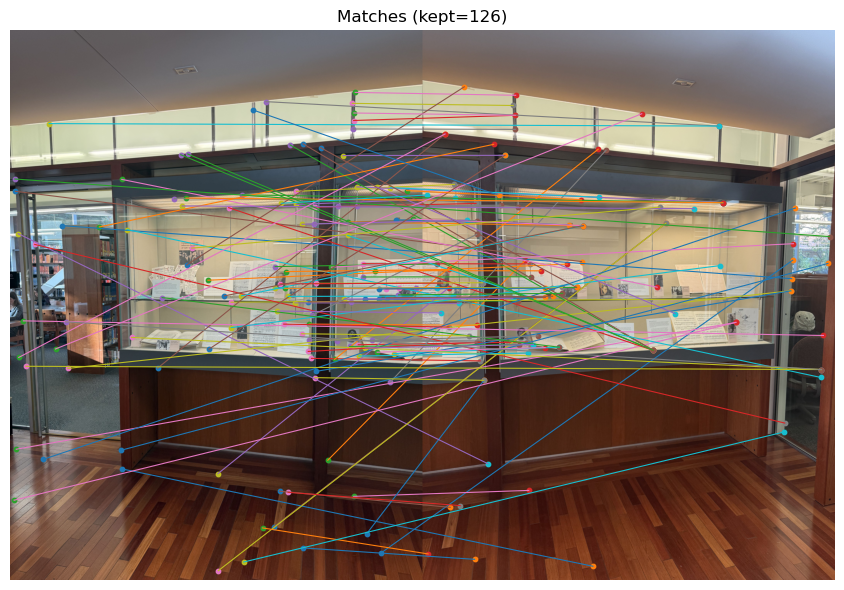

In [26]:
imA_path = "./media/lib1.jpg"
imB_path = "./media/lib2.jpg"
scale = 0.5

# --- load + grayscale ---
rgb1 = imread(imA_path)
rgb2 = imread(imB_path)
g1 = rgb2gray(rgb1).astype(np.float32)
g2 = rgb2gray(rgb2).astype(np.float32)

# --- downscale for detection and display (must be the same scale) ---
im_small_1  = rescale(g1, scale, anti_aliasing=True)
im_small_2  = rescale(g2, scale, anti_aliasing=True)
rgb_small_1 = rescale(rgb1, scale, anti_aliasing=True, channel_axis=-1)
rgb_small_2 = rescale(rgb2, scale, anti_aliasing=True, channel_axis=-1)

# --- Harris + (optional) sparser settings ---
h1, c1 = get_harris_corners(im_small_1, edge_discard=20)
h2, c2 = get_harris_corners(im_small_2, edge_discard=20)

# --- ANMS (keeps well-distributed points) ---
kp1 = anms(c1, h1, N=600, c_robust=0.9)     # shape (2, M1)  (ys; xs)
kp2 = anms(c2, h2, N=600, c_robust=0.9)     # shape (2, M2)

# --- 8×8 descriptors from 40×40 windows (axis-aligned) ---
D1, kp1 = extract_descriptors_8x8(im_small_1, kp1, win_size=40, desc_size=8, blur_sigma=1.0)
D2, kp2 = extract_descriptors_8x8(im_small_2, kp2, win_size=40, desc_size=8, blur_sigma=1.0)

# --- L2-normalize descriptors (helps matching) ---
D1n = D1 / (np.linalg.norm(D1, axis=1, keepdims=True) + 1e-6)
D2n = D2 / (np.linalg.norm(D2, axis=1, keepdims=True) + 1e-6)

# --- match with Lowe ratio + mutual consistency ---
# i1, i2, ratio = match_descriptors(D1n, D2n, ratio_thresh=0.7, mutual=True)
# print(f"kept {len(i1)} matches (ratio<0.7, mutual)")
# slightly more permissive matching
i1, i2, ratio = match_descriptors(D1n, D2n, ratio_thresh=0.8, mutual=False)
print("raw matches:", len(i1))


# --- visualize ---
show_matches(rgb_small_1, kp1, rgb_small_2, kp2, i1, i2,
             title=f"Matches (kept={len(i1)})", max_draw=120)


In [36]:
import numpy as np
rng = np.random.default_rng(0)

def quad_area(pts):
    # pts: (4,2) in (x,y)
    x, y = pts[:,0], pts[:,1]
    return 0.5 * abs(np.sum(x*np.roll(y,-1) - y*np.roll(x,-1)))

def symmetric_transfer_error(H, pts1_xy, pts2_xy):
    N = pts1_xy.shape[0]
    p1 = np.c_[pts1_xy, np.ones(N)]
    p2 = np.c_[pts2_xy, np.ones(N)]

    Hp1 = (H @ p1.T).T
    Hp1 = Hp1[:, :2] / Hp1[:, 2:3]

    Hinv = np.linalg.inv(H)
    Hinvp2 = (Hinv @ p2.T).T
    Hinvp2 = Hinvp2[:, :2] / Hinvp2[:, 2:3]

    return np.linalg.norm(Hp1 - pts2_xy, axis=1) + np.linalg.norm(Hinvp2 - pts1_xy, axis=1)

def ransac_homography(kp1_yx, kp2_yx, i1, i2, iters=5000, thresh=4.0, min_inliers=10, area_min=8.0):
    """
    kp*_yx: (2,M) = (y,x) at SAME SCALE as descriptors
    i1,i2:  match indices
    thresh: symmetric transfer error in *pixels* at current scale
    area_min: min quadrilateral area (in px^2) to avoid near-collinear samples
    """
    if len(i1) < 4:
        raise ValueError("Need at least 4 matches")

    # (y,x) -> (x,y)
    pts1_xy = kp1_yx[:, i1].T[:, [1,0]].astype(float)
    pts2_xy = kp2_yx[:, i2].T[:, [1,0]].astype(float)

    best_inliers, best_H, best_count = None, None, -1
    N = pts1_xy.shape[0]

    for _ in range(iters):
        idx = rng.choice(N, size=4, replace=False)
        p1 = pts1_xy[idx]
        p2 = pts2_xy[idx]

        # reject degenerate samples
        if quad_area(p1) < area_min or quad_area(p2) < area_min:
            continue

        try:
            Hcand = computeH(p1, p2)  # your normalized DLT (expects (x,y))
            if not np.isfinite(Hcand).all():
                continue
        except np.linalg.LinAlgError:
            continue

        errs = symmetric_transfer_error(Hcand, pts1_xy, pts2_xy)
        inliers = errs < thresh
        count = int(inliers.sum())

        if count > best_count:
            best_count = count
            best_inliers = inliers
            best_H = Hcand

    if best_inliers is None or best_count < min_inliers:
        raise RuntimeError("RANSAC failed to find a good homography")

    H_refit = computeH(pts1_xy[best_inliers], pts2_xy[best_inliers])
    return H_refit, best_inliers


/var/folders/1j/2tm4cv2s2vndcm34yjt_7t640000gn/T/ipykernel_54651/515822756.py:15: RuntimeWarning: divide by zero encountered in divide
  Hp1 = Hp1[:, :2] / Hp1[:, 2:3]
/var/folders/1j/2tm4cv2s2vndcm34yjt_7t640000gn/T/ipykernel_54651/515822756.py:15: RuntimeWarning: invalid value encountered in divide
  Hp1 = Hp1[:, :2] / Hp1[:, 2:3]
/var/folders/1j/2tm4cv2s2vndcm34yjt_7t640000gn/T/ipykernel_54651/515822756.py:19: RuntimeWarning: divide by zero encountered in divide
  Hinvp2 = Hinvp2[:, :2] / Hinvp2[:, 2:3]
/var/folders/1j/2tm4cv2s2vndcm34yjt_7t640000gn/T/ipykernel_54651/515822756.py:19: RuntimeWarning: invalid value encountered in divide
  Hinvp2 = Hinvp2[:, :2] / Hinvp2[:, 2:3]


Inliers: 11 / 189


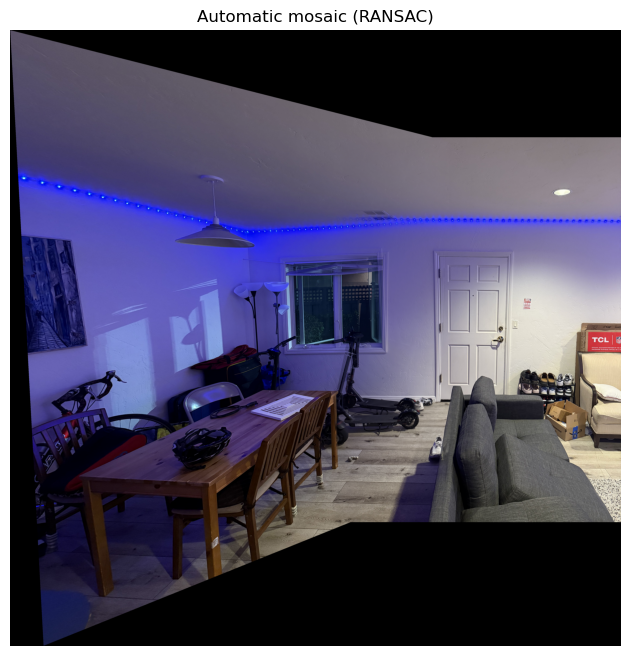

In [37]:
H_auto, inliers = ransac_homography(kp1, kp2, i1, i2, iters=2000, thresh=2.5)
print(f"Inliers: {inliers.sum()} / {len(i1)}")

# Convert small RGBs (float in [0,1]) to uint8 in [0,255]
im1_small_u8 = (rgb_small_1 * 255).astype(np.uint8)
im2_small_u8 = (rgb_small_2 * 255).astype(np.uint8)

# H_auto maps image1 -> image2 at the small scale
out_shape, T = mosaic_bounds(im1_small_u8, im2_small_u8, H_auto)
H_total = T @ H_auto

im1_warped = warpImageBilinear(im1_small_u8, H_total, out_shape)

# paste image2 onto canvas (your code)
mosaic = np.zeros_like(im1_warped)
h2, w2 = im2_small_u8.shape[:2]
tx, ty = T[0,2], T[1,2]
for i in range(h2):
    for j in range(w2):
        x = int(j + tx); y = int(i + ty)
        if 0 <= y < mosaic.shape[0] and 0 <= x < mosaic.shape[1]:
            mosaic[y, x] = im2_small_u8[i, j]

# Feathered blend (your distance-transform trick)
from scipy.ndimage import distance_transform_edt

def alpha_from_valid(mask):
    return distance_transform_edt(mask) / (distance_transform_edt(~mask) + 1e-6)

valid1 = (im1_warped.sum(axis=2) > 0)
valid2 = (mosaic.sum(axis=2) > 0)
a1 = alpha_from_valid(valid1)
a2 = alpha_from_valid(valid2) * 1.3  # small bias toward unwarped image2

W = (a1 + a2 + 1e-6)[..., None]
mosaic_blend = (im1_warped * a1[...,None] + mosaic * a2[...,None]) / W
mosaic_blend = np.clip(mosaic_blend, 0, 255).astype(np.uint8)

plt.figure(figsize=(8,8))
plt.imshow(mosaic_blend); plt.axis('off'); plt.title("Automatic mosaic (RANSAC)")
plt.show()
